In [3]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
data = pd.read_csv("C:\\Learning_ML\\ML_Projects\\Loan_Approval_Model\\loan_data_new.csv")
print(data.head())
# profile = ProfileReport(data, explorative=True)
# profile.to_file("report.html")

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08               2           504  

In [5]:
TARGET = "Loan Status"
X = data.drop(columns=[TARGET])
y = data[TARGET]
print(X.head())

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  
0             0.49               3           561            No  
1             0.08               2           504           Yes  
2          

In [6]:
# Identify column types automatically
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
Numerical columns: ['Age', 'Person Income', 'Employee Experience', 'Loan Amount', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score']


In [7]:
data.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [8]:
print(data['Age'].mode())

0    23
Name: Age, dtype: int64


In [9]:
print((data['Age'] == 21).sum())
print((data['Age'] == 22).sum()) # 22 has a large jump count after 21
print((data['Age'] == 23).sum()) # 23 has largest number of count
print((data['Age'] == 24).sum()) # 24 has second largest number of count
# 23 and 24 have maximum count and 22 has a large jump after 21. So we can say that the mode of age is 23 and 24.

1289
4236
5254
5138


In [10]:
print(data['Age'].median())

26.0


In [11]:
print(data['Age'].count())

45000


In [12]:
print((data['Age'] == 30).sum())
sum=0
for c in data['Age']:
    if c>=27 and c<=30:
        sum+=1
print(sum)

2021
10299


In [13]:
# to store unique values of education
res = [] 
for i in data['Education']:
    if i not in res:
        res.append(i)
print(res)

# to store count of each unique value of education
d = {} 
for i in res:
    d[i] = int((data['Education'] == i).sum())
print(d)

['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
{'Master': 6980, 'High School': 11972, 'Bachelor': 13399, 'Associate': 12028, 'Doctorate': 621}


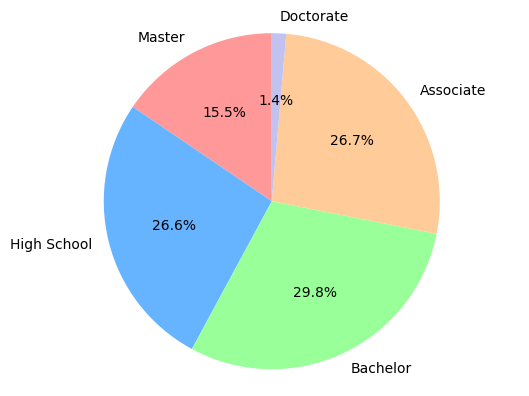

In [14]:
sizes = list(d.values())
labels = res

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99','#c2c2f0','#ffb3e6']
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.axis('equal')
plt.show(block=True)

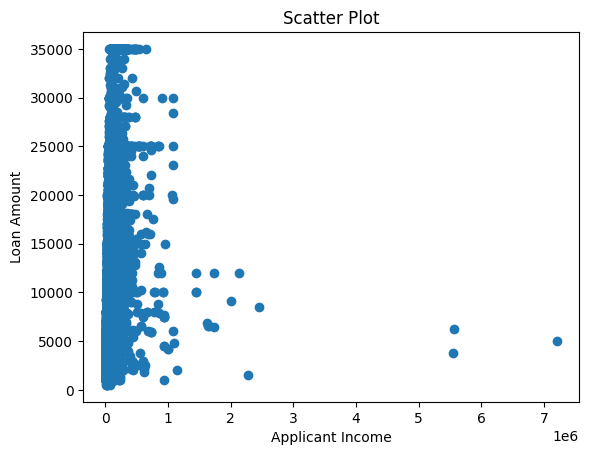

In [15]:
plt.scatter(data['Person Income'], data['Loan Amount'])
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Scatter Plot')
plt.show()

# got few outliers in the scatter plot. So we can remove them by using IQR method.

In [16]:
# Apply data preprocessing techniques such as scaling and encoding to prepare the data for modeling.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
    ]
)